# creates inputs and runs full analysis

In [1]:
from full_analysis_vSpeed2 import full_analysis_vSpeed2
from full_analysis_vSpeed3 import full_analysis_vSpeed3
from pathlib import Path
import pandas as pd
import numpy as np
from analysis_utils import downscale_binary_video

In [2]:
# %%
#jobFolder_str=r"GBM11\g11_0409_zebra"
jobFolder_str=r"GBM11\g11_0409_zebra5"
#jobFolder_str=r"GBM11\g11_0415_zebra5"
#jobFolder_str=r"GBM11\g11_0423_zebra6"
#jobFolder_str=r"GBM11\g11_0508_full"
#jobFolder_str=r"GBM15\g15_0408_zebra"
#jobFolder_str=r"GBM15\g15_0422_zebra3"

# %%
spks_path = "D:\\SynologyDriveSyncedDATA\\PROCESSED\\GBM\\" +  jobFolder_str + "\\ZEBRA_ANALYSIS\\resps_all.npy"

In [ ]:
#downsample video

full_screen_coverage = [-88, 0, -33, 33] 
visual_coverage = [-88, 0, -33, 33]
screen_x = 100
videopath = r'D:\SynologyDriveSyncedDATA\PROCESSED\Waven\zebra_s0_d420.0_fps59.94_RESAMPLED30fps.mp4'

downsampled_video_path=downscale_binary_video(videopath, full_screen_coverage, visual_coverage, screen_x, screen_y=None, force=False)

Calculated screen_y=75 to keep aspect ratio of visual coverage.
Generating cropped and downsampled binary video...
Output file D:\SynologyDriveSyncedDATA\PROCESSED\Waven\zebra_s0_d420.0_fps59.94_RESAMPLED30fps_scaled100x75.npy already exists. Skipping generation.


In [4]:
#load stat summary to load, append new results to it
stat_summary_file=Path(spks_path).parent / "stat_summary.xlsx"
if not stat_summary_file.exists():
    print("stat_summary_file does not exist")
    

In [5]:
spks=np.load(spks_path)

In [6]:
# Gauss averaging along dimension 1 with set FWHM (target_fps=30)
from scipy.ndimage import gaussian_filter1d
target_fps = 30

average_FWHM_sec = 0.1 #sec
average_FWHM_samples = int(np.round(target_fps * average_FWHM_sec))

#spks = gaussian_filter1d(spks, sigma=average_FWHM_samples / 2.355,  axis=1) #sigma = FWHM / (2*sqrt(2*ln(2)))
#print(f"Time-averaged spks with FWHM={average_FWHM_sec} sec, {average_FWHM_samples} samples, ")

D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0409_zebra5\ZEBRA_ANALYSIS\resps_all.npy
Screen size: 100x75 pixels
Full screen coverage: [-88, 0, -33, 33] degrees
Visual coverage: [-88, 0, -33, 33] degrees
Angles (degrees): [  0.   22.5  45.   67.5  90.  112.5 135.  157.5]
Sizes (degrees): [ 4.          5.51891865  7.61461575 10.50611122 14.49559327 20.        ]
Frequencies (cycles/degree): [0.025      0.03912711 0.06123724 0.09584147 0.15      ]
Phases (degrees): [ 0. 90.]
Drifts (degrees/frame): [-4.         -2.66666667 -1.33333333  0.          1.33333333  2.66666667
  4.        ]
Total number of Gabor filters to generate: 80640
Control: Gabor placement step in visual degrees (x): 14.7, vs size_min: 4.0 degrees. WARNING!
Control: Gabor placement step in visual degrees (y): 16.5, vs size_min: 4.0 degrees. WARNING!
Control: Gabor resolution in visual degrees (x): 0.9, vs 1/freq_max: 6.7 degrees. OK
Control: Gabor resolution in visual degrees (y): 0.9, vs 1/freq_max: 6.7 degrees. OK

Computing split-half correlation per neuron: 100%|██████████| 2254/2254 [00:35<00:00, 63.04it/s] 


Working directory: D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0409_zebra5\ZEBRA_ANALYSIS
Train split at 85.0% of timepoints, test split at 15.0% of timepoints
Saved Gabor filter parameters to D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0409_zebra5\ZEBRA_ANALYSIS\gaborLibrary_vS_6_4_8_6_5_7_2_af1d308a_c.s3.d1_
>>>>>>>>dwt shape: (12600, 6, 4, 8, 6, 5, 7, 2)
Using dwt mode: c.s3.d1_orig, feature dimension number: 7


Gaussian smoothing: 100%|██████████| 5/5 [00:07<00:00,  1.47s/it]


    stim_flat shape: (10710, 80640) (n_timepoints=10710, n_features=80640)
    resp shape: (10710, 2254) (n_timepoints=10710, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 9/9 [00:01<00:00,  4.52it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    92.09 MB  | shape=(2254, 10710)  dtype=torch.float32
| S_chunk             :    26.15 MB  | shape=(640, 10710)  dtype=torch.float32
| rfs_chunk           :     5.50 MB  | shape=(2254, 640)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   123.74 MB (  1.0%) | RESERVED:  1830.00 MB ( 14.9%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 6, 4, 8, 6, 5, 7, 2) (neurons=2254, feature_dims=(6, 4, 8, 6, 5, 7, 2))
Mean respcorr of largest 20 neurons: 0.603
Mean rfs_correlation of largest 20 neurons (train performance): 0.137
Mean rfs_correlation of largest 20 neurons (test performance): 0.052


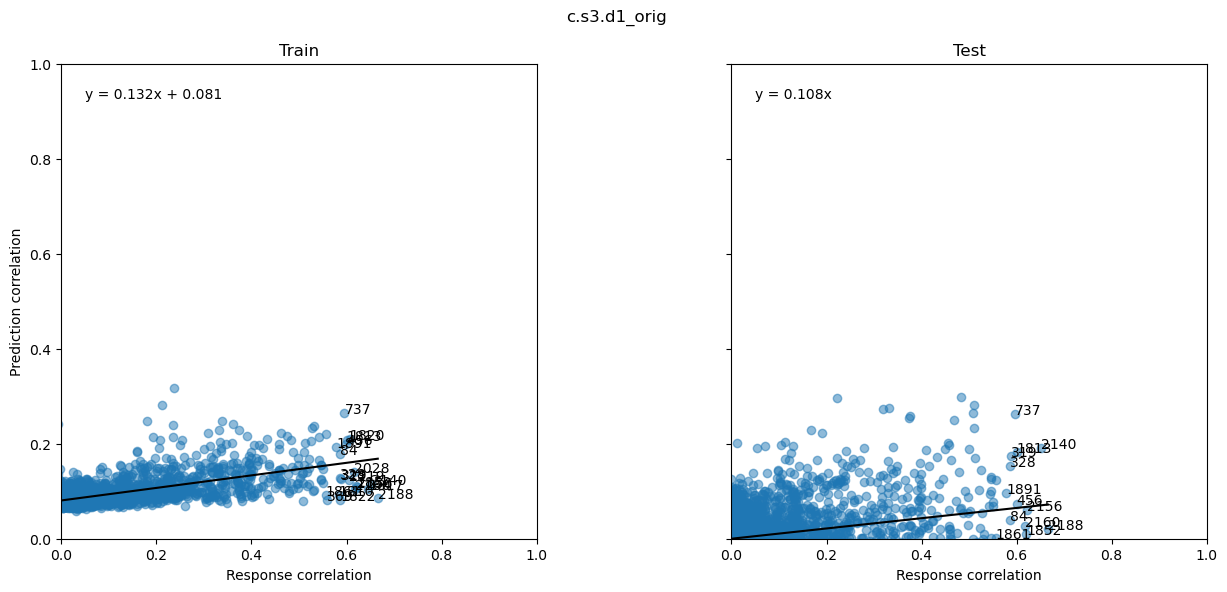

train fit: y = 0.131911 x + 0.080570
test fit : y = 0.107955 x
Using dwt mode: c.s3.d1_Gt0, feature dimension number: 7


Gaussian smoothing: 100%|██████████| 5/5 [00:06<00:00,  1.27s/it]


    stim_flat shape: (10710, 80640) (n_timepoints=10710, n_features=80640)
    resp shape: (10710, 2254) (n_timepoints=10710, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 9/9 [00:01<00:00,  4.59it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    92.09 MB  | shape=(2254, 10710)  dtype=torch.float32
| S_chunk             :    26.15 MB  | shape=(640, 10710)  dtype=torch.float32
| rfs_chunk           :     5.50 MB  | shape=(2254, 640)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   123.74 MB (  1.0%) | RESERVED:  1642.00 MB ( 13.4%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 6, 4, 8, 6, 5, 7, 2) (neurons=2254, feature_dims=(6, 4, 8, 6, 5, 7, 2))
Mean respcorr of largest 20 neurons: 0.603
Mean rfs_correlation of largest 20 neurons (train performance): 0.274
Mean rfs_correlation of largest 20 neurons (test performance): 0.202


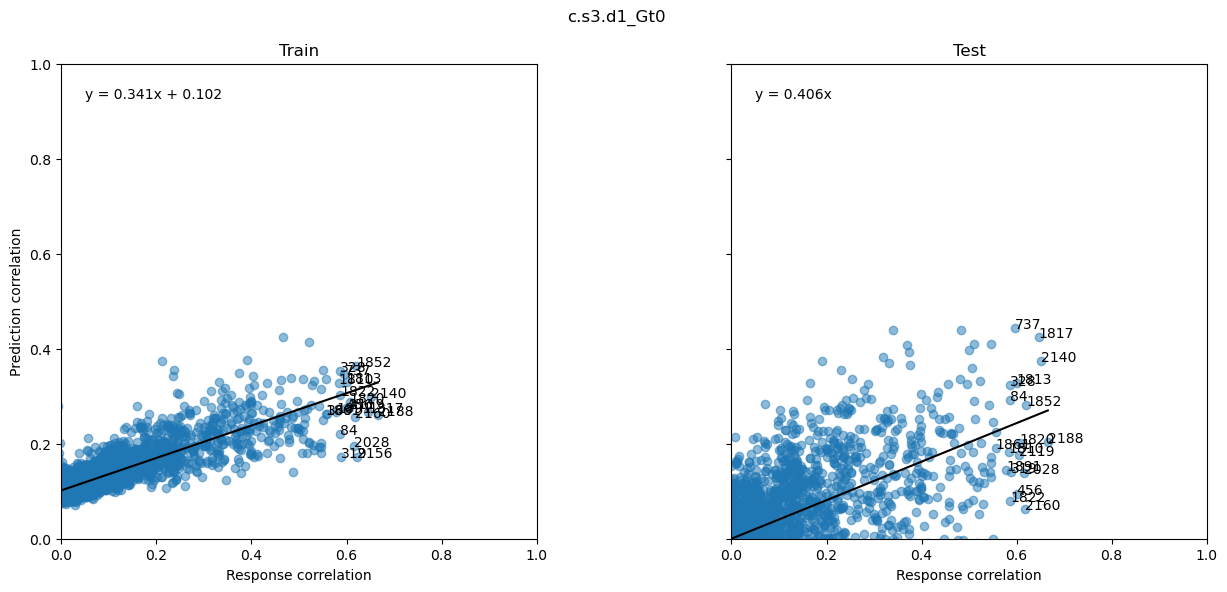

train fit: y = 0.340742 x + 0.101843
test fit : y = 0.405505 x
Using dwt mode: c.s3.d1_Gt0^2, feature dimension number: 7


Gaussian smoothing: 100%|██████████| 5/5 [00:07<00:00,  1.60s/it]


    stim_flat shape: (10710, 80640) (n_timepoints=10710, n_features=80640)
    resp shape: (10710, 2254) (n_timepoints=10710, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 9/9 [00:01<00:00,  4.98it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    92.09 MB  | shape=(2254, 10710)  dtype=torch.float32
| S_chunk             :    26.15 MB  | shape=(640, 10710)  dtype=torch.float32
| rfs_chunk           :     5.50 MB  | shape=(2254, 640)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   123.74 MB (  1.0%) | RESERVED:  1642.00 MB ( 13.4%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 6, 4, 8, 6, 5, 7, 2) (neurons=2254, feature_dims=(6, 4, 8, 6, 5, 7, 2))
Mean respcorr of largest 20 neurons: 0.603
Mean rfs_correlation of largest 20 neurons (train performance): 0.298
Mean rfs_correlation of largest 20 neurons (test performance): 0.190


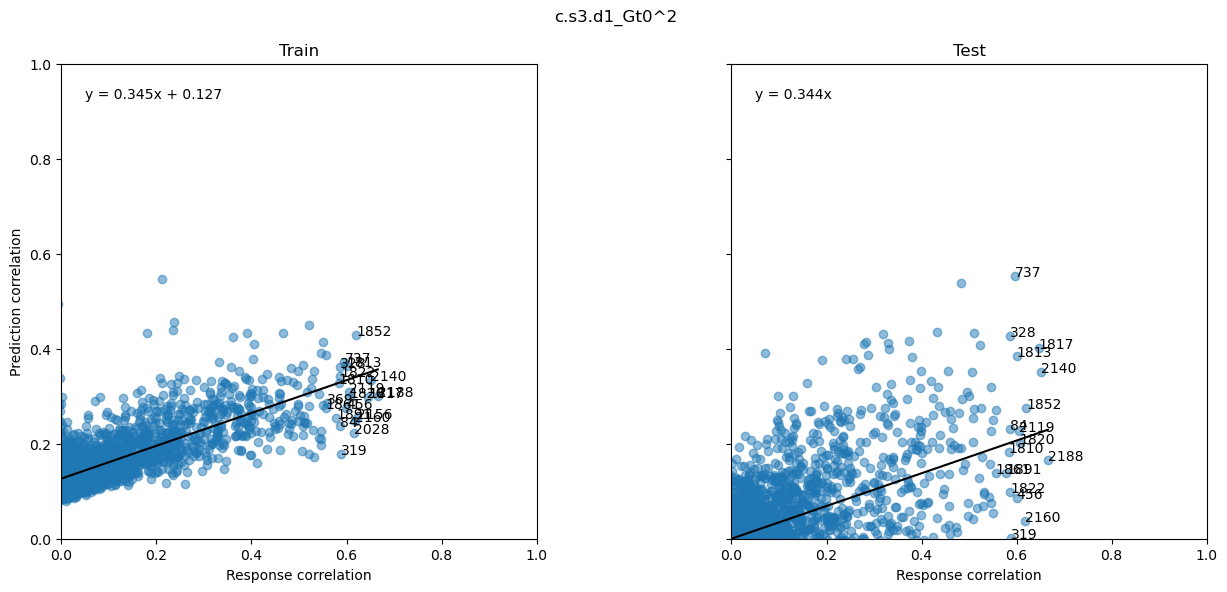

train fit: y = 0.345124 x + 0.126568
test fit : y = 0.344343 x
Using dwt mode: c.s3.d1_Gt0_rt, feature dimension number: 7


Gaussian smoothing: 100%|██████████| 5/5 [00:06<00:00,  1.21s/it]


    stim_flat shape: (10710, 80640) (n_timepoints=10710, n_features=80640)
    resp shape: (10710, 2254) (n_timepoints=10710, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 9/9 [00:01<00:00,  4.80it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    92.09 MB  | shape=(2254, 10710)  dtype=torch.float32
| S_chunk             :    26.15 MB  | shape=(640, 10710)  dtype=torch.float32
| rfs_chunk           :     5.50 MB  | shape=(2254, 640)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   123.74 MB (  1.0%) | RESERVED:  1642.00 MB ( 13.4%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 6, 4, 8, 6, 5, 7, 2) (neurons=2254, feature_dims=(6, 4, 8, 6, 5, 7, 2))
Mean respcorr of largest 20 neurons: 0.603
Mean rfs_correlation of largest 20 neurons (train performance): 0.222
Mean rfs_correlation of largest 20 neurons (test performance): 0.166


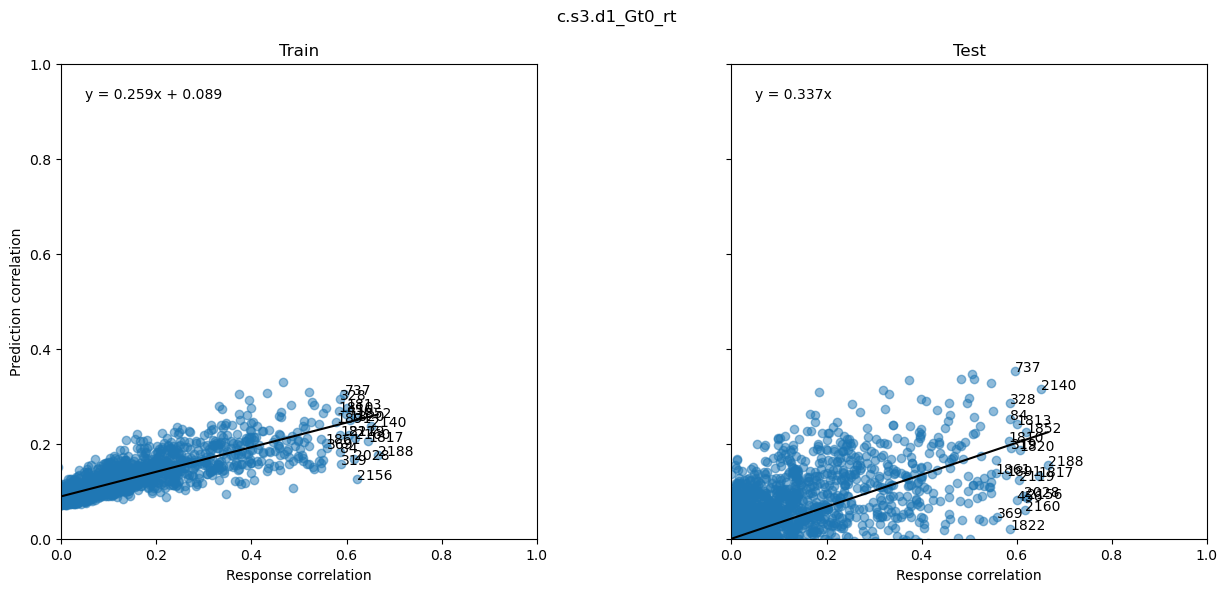

train fit: y = 0.258517 x + 0.089288
test fit : y = 0.336508 x
Using dwt mode: c.s3.d1_abs, feature dimension number: 7


Gaussian smoothing: 100%|██████████| 5/5 [00:05<00:00,  1.17s/it]


    stim_flat shape: (10710, 80640) (n_timepoints=10710, n_features=80640)
    resp shape: (10710, 2254) (n_timepoints=10710, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 9/9 [00:02<00:00,  4.48it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    92.09 MB  | shape=(2254, 10710)  dtype=torch.float32
| S_chunk             :    26.15 MB  | shape=(640, 10710)  dtype=torch.float32
| rfs_chunk           :     5.50 MB  | shape=(2254, 640)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   123.74 MB (  1.0%) | RESERVED:  1642.00 MB ( 13.4%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 6, 4, 8, 6, 5, 7, 2) (neurons=2254, feature_dims=(6, 4, 8, 6, 5, 7, 2))
Mean respcorr of largest 20 neurons: 0.603
Mean rfs_correlation of largest 20 neurons (train performance): 0.339
Mean rfs_correlation of largest 20 neurons (test performance): 0.232


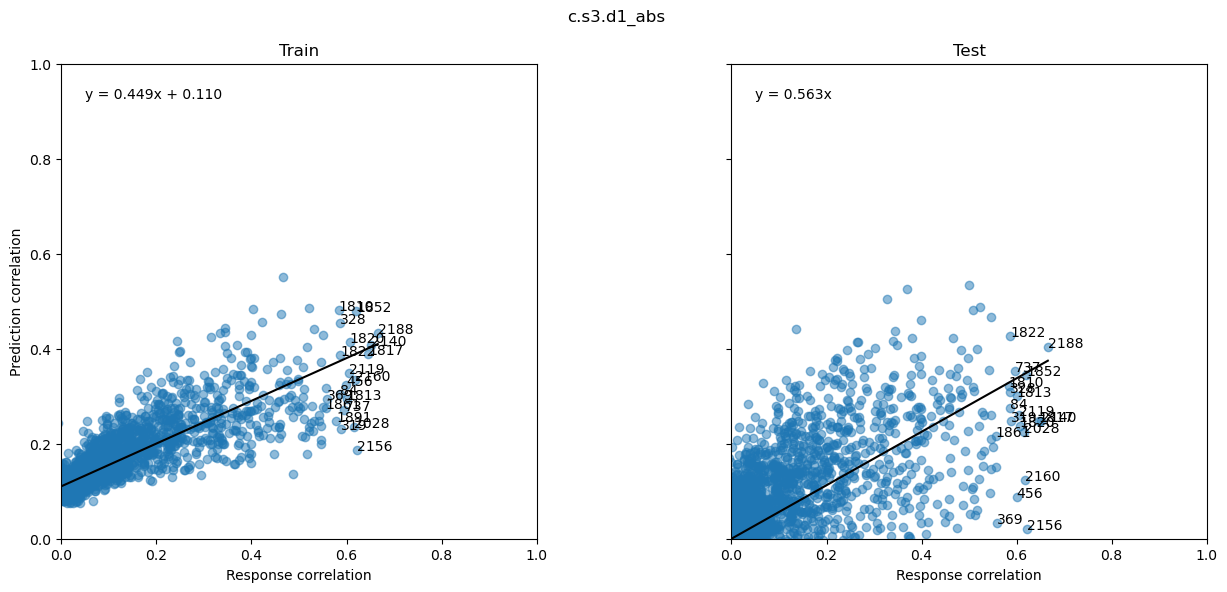

train fit: y = 0.449493 x + 0.110414
test fit : y = 0.562658 x
Using dwt mode: c.s3.d1_abs^2, feature dimension number: 7


Gaussian smoothing: 100%|██████████| 5/5 [00:06<00:00,  1.30s/it]


    stim_flat shape: (10710, 80640) (n_timepoints=10710, n_features=80640)
    resp shape: (10710, 2254) (n_timepoints=10710, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 9/9 [00:01<00:00,  4.82it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    92.09 MB  | shape=(2254, 10710)  dtype=torch.float32
| S_chunk             :    26.15 MB  | shape=(640, 10710)  dtype=torch.float32
| rfs_chunk           :     5.50 MB  | shape=(2254, 640)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   123.74 MB (  1.0%) | RESERVED:  1642.00 MB ( 13.4%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 6, 4, 8, 6, 5, 7, 2) (neurons=2254, feature_dims=(6, 4, 8, 6, 5, 7, 2))
Mean respcorr of largest 20 neurons: 0.603
Mean rfs_correlation of largest 20 neurons (train performance): 0.350
Mean rfs_correlation of largest 20 neurons (test performance): 0.234


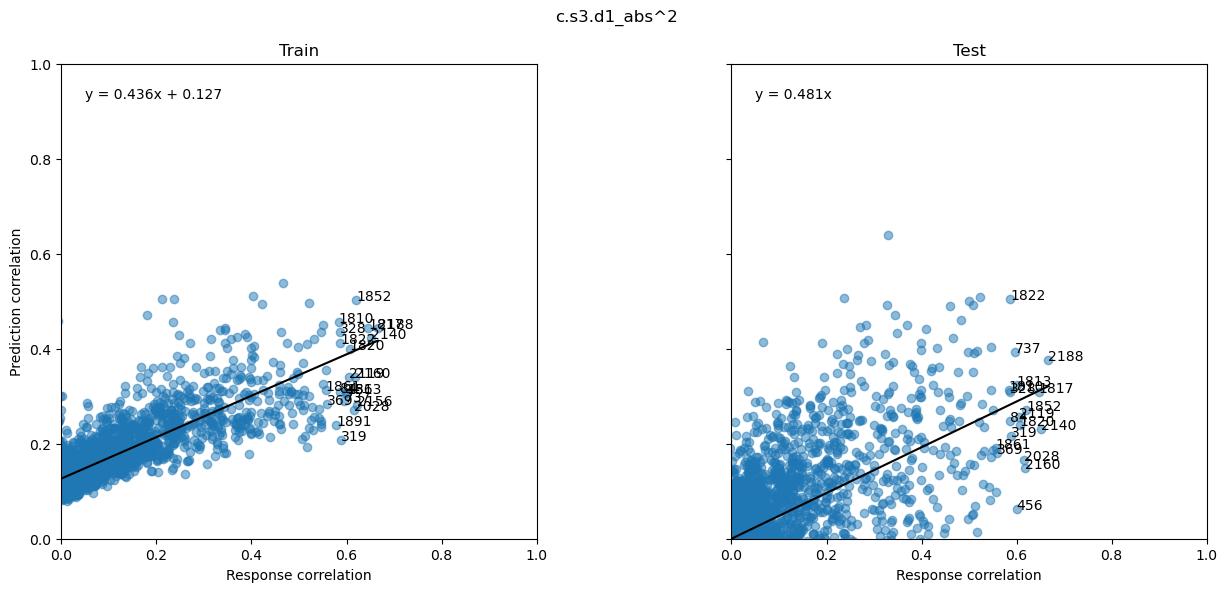

train fit: y = 0.435632 x + 0.126683
test fit : y = 0.481288 x
Using dwt mode: c.s3.d1_abs_rt, feature dimension number: 7


Gaussian smoothing: 100%|██████████| 5/5 [00:05<00:00,  1.15s/it]


    stim_flat shape: (10710, 80640) (n_timepoints=10710, n_features=80640)
    resp shape: (10710, 2254) (n_timepoints=10710, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 9/9 [00:01<00:00,  4.79it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    92.09 MB  | shape=(2254, 10710)  dtype=torch.float32
| S_chunk             :    26.15 MB  | shape=(640, 10710)  dtype=torch.float32
| rfs_chunk           :     5.50 MB  | shape=(2254, 640)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   123.74 MB (  1.0%) | RESERVED:  1642.00 MB ( 13.4%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 6, 4, 8, 6, 5, 7, 2) (neurons=2254, feature_dims=(6, 4, 8, 6, 5, 7, 2))
Mean respcorr of largest 20 neurons: 0.603
Mean rfs_correlation of largest 20 neurons (train performance): 0.317
Mean rfs_correlation of largest 20 neurons (test performance): 0.245


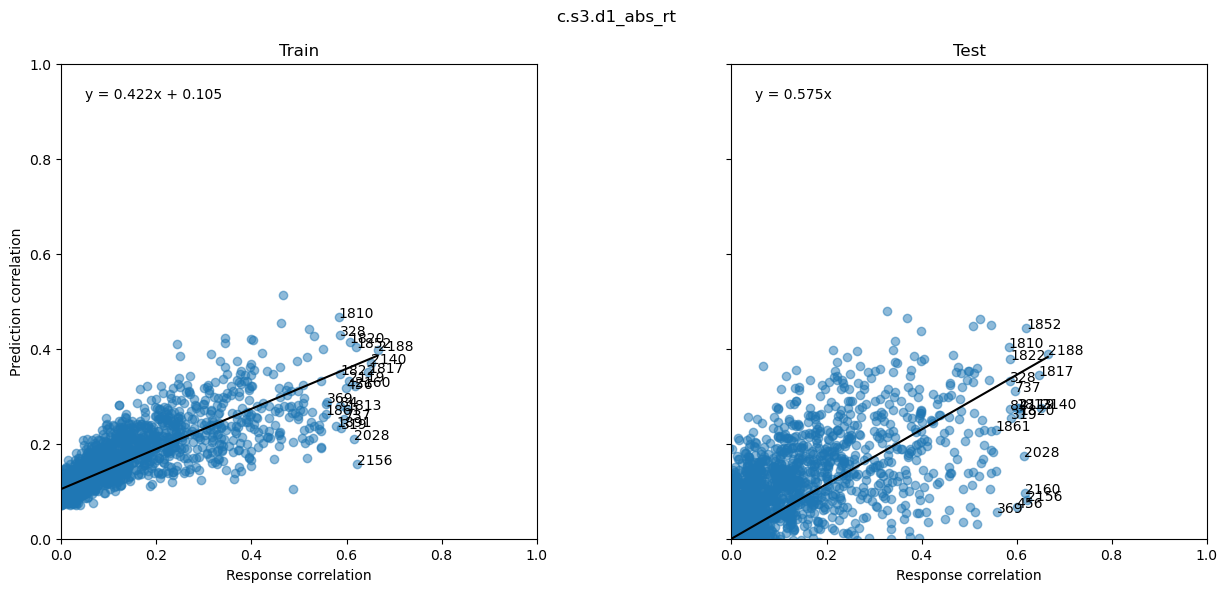

train fit: y = 0.421579 x + 0.104808
test fit : y = 0.574605 x
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Calculating DWT amplitude and phase: 100%|██████████| 50/50 [00:01<00:00, 34.46it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| batch               :    17.23 MB  | shape=(56, 6, 4, 8, 6, 5, 7, 2)  dtype=torch.float32
| real                :     8.61 MB  | shape=(56, 6, 4, 8, 6, 5, 7)  dtype=torch.float32
| imag                :     8.61 MB  | shape=(56, 6, 4, 8, 6, 5, 7)  dtype=torch.float32
| amp                 :     8.61 MB  | shape=(56, 6, 4, 8, 6, 5, 7)  dtype=torch.float32
| phase               :     8.61 MB  | shape=(56, 6, 4, 8, 6, 5, 7)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:    51.68 MB (  0.4%) | RESERVED:   410.00 MB (  3.3%) | TOTAL GPU: 12281.50 MB  
Using dwt mode: c.s3.d1_cA, feature dimension number: 6


Gaussian smoothing: 100%|██████████| 3/3 [00:02<00:00,  1.11it/s]


    stim_flat shape: (10710, 40320) (n_timepoints=10710, n_features=40320)
    resp shape: (10710, 2254) (n_timepoints=10710, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 5/5 [00:01<00:00,  3.62it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    92.09 MB  | shape=(2254, 10710)  dtype=torch.float32
| S_chunk             :    13.07 MB  | shape=(320, 10710)  dtype=torch.float32
| rfs_chunk           :     2.75 MB  | shape=(2254, 320)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   107.91 MB (  0.9%) | RESERVED:  1642.00 MB ( 13.4%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 6, 4, 8, 6, 5, 7) (neurons=2254, feature_dims=(6, 4, 8, 6, 5, 7))
Mean respcorr of largest 20 neurons: 0.603
Mean rfs_correlation of largest 20 neurons (train performance): 0.354
Mean rfs_correlation of largest 20 neurons (test performance): 0.283


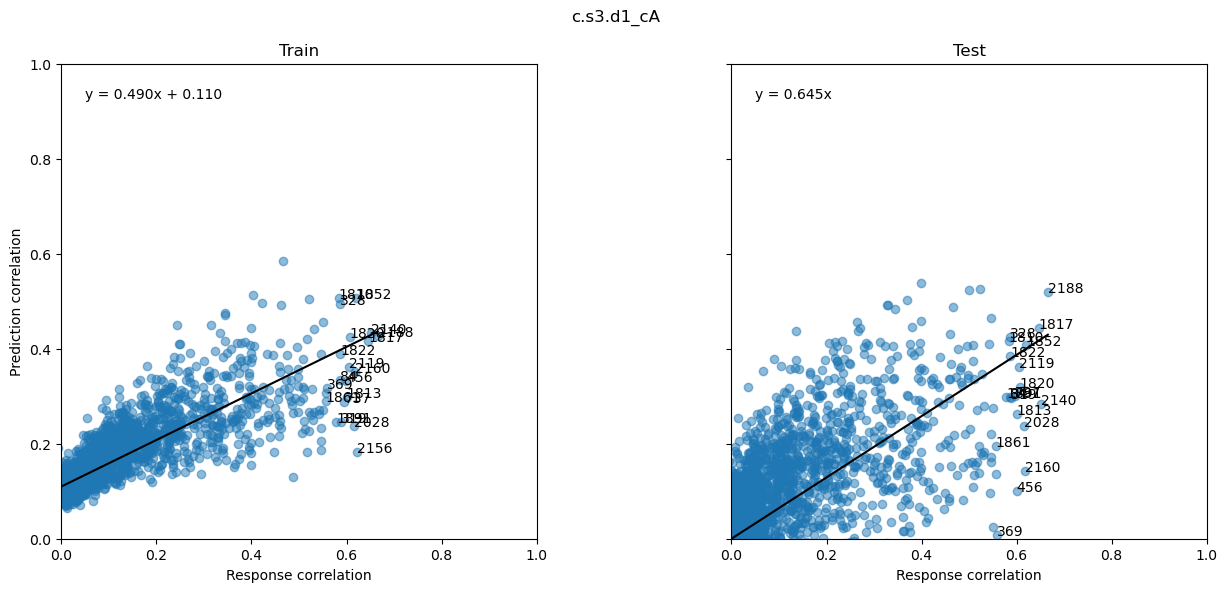

train fit: y = 0.489710 x + 0.109900
test fit : y = 0.644815 x
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Calculating DWT amplitude and phase: 100%|██████████| 50/50 [00:01<00:00, 38.98it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| batch               :    17.23 MB  | shape=(56, 6, 4, 8, 6, 5, 7, 2)  dtype=torch.float32
| real                :     8.61 MB  | shape=(56, 6, 4, 8, 6, 5, 7)  dtype=torch.float32
| imag                :     8.61 MB  | shape=(56, 6, 4, 8, 6, 5, 7)  dtype=torch.float32
| amp                 :     8.61 MB  | shape=(56, 6, 4, 8, 6, 5, 7)  dtype=torch.float32
| phase               :     8.61 MB  | shape=(56, 6, 4, 8, 6, 5, 7)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:    51.68 MB (  0.4%) | RESERVED:   410.00 MB (  3.3%) | TOTAL GPU: 12281.50 MB  
Using dwt mode: c.s3.d1_cA^2, feature dimension number: 6


Gaussian smoothing: 100%|██████████| 3/3 [00:02<00:00,  1.20it/s]


    stim_flat shape: (10710, 40320) (n_timepoints=10710, n_features=40320)
    resp shape: (10710, 2254) (n_timepoints=10710, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 5/5 [00:01<00:00,  3.55it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    92.09 MB  | shape=(2254, 10710)  dtype=torch.float32
| S_chunk             :    13.07 MB  | shape=(320, 10710)  dtype=torch.float32
| rfs_chunk           :     2.75 MB  | shape=(2254, 320)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   107.91 MB (  0.9%) | RESERVED:  1642.00 MB ( 13.4%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 6, 4, 8, 6, 5, 7) (neurons=2254, feature_dims=(6, 4, 8, 6, 5, 7))
Mean respcorr of largest 20 neurons: 0.603
Mean rfs_correlation of largest 20 neurons (train performance): 0.370
Mean rfs_correlation of largest 20 neurons (test performance): 0.292


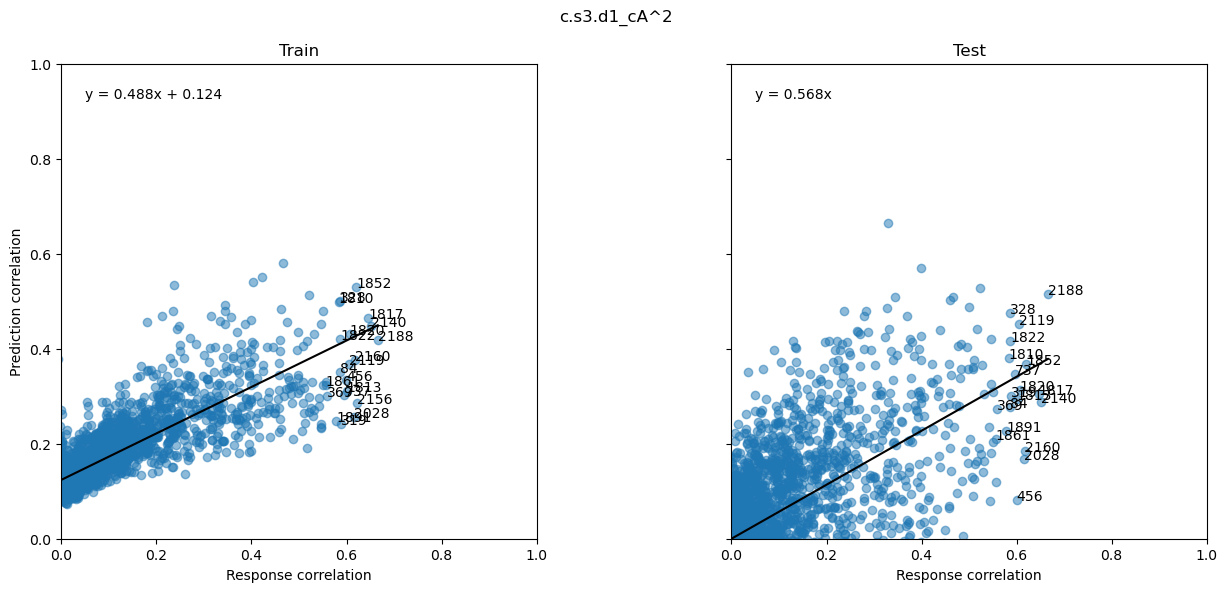

train fit: y = 0.488497 x + 0.123970
test fit : y = 0.568087 x
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Calculating DWT amplitude and phase: 100%|██████████| 50/50 [00:01<00:00, 35.60it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| batch               :    17.23 MB  | shape=(56, 6, 4, 8, 6, 5, 7, 2)  dtype=torch.float32
| real                :     8.61 MB  | shape=(56, 6, 4, 8, 6, 5, 7)  dtype=torch.float32
| imag                :     8.61 MB  | shape=(56, 6, 4, 8, 6, 5, 7)  dtype=torch.float32
| amp                 :     8.61 MB  | shape=(56, 6, 4, 8, 6, 5, 7)  dtype=torch.float32
| phase               :     8.61 MB  | shape=(56, 6, 4, 8, 6, 5, 7)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:    51.68 MB (  0.4%) | RESERVED:   410.00 MB (  3.3%) | TOTAL GPU: 12281.50 MB  
Using dwt mode: c.s3.d1_cA_rt, feature dimension number: 6


Gaussian smoothing: 100%|██████████| 3/3 [00:02<00:00,  1.19it/s]


    stim_flat shape: (10710, 40320) (n_timepoints=10710, n_features=40320)
    resp shape: (10710, 2254) (n_timepoints=10710, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 5/5 [00:01<00:00,  3.54it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    92.09 MB  | shape=(2254, 10710)  dtype=torch.float32
| S_chunk             :    13.07 MB  | shape=(320, 10710)  dtype=torch.float32
| rfs_chunk           :     2.75 MB  | shape=(2254, 320)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   107.91 MB (  0.9%) | RESERVED:  1642.00 MB ( 13.4%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 6, 4, 8, 6, 5, 7) (neurons=2254, feature_dims=(6, 4, 8, 6, 5, 7))
Mean respcorr of largest 20 neurons: 0.603
Mean rfs_correlation of largest 20 neurons (train performance): 0.331
Mean rfs_correlation of largest 20 neurons (test performance): 0.299


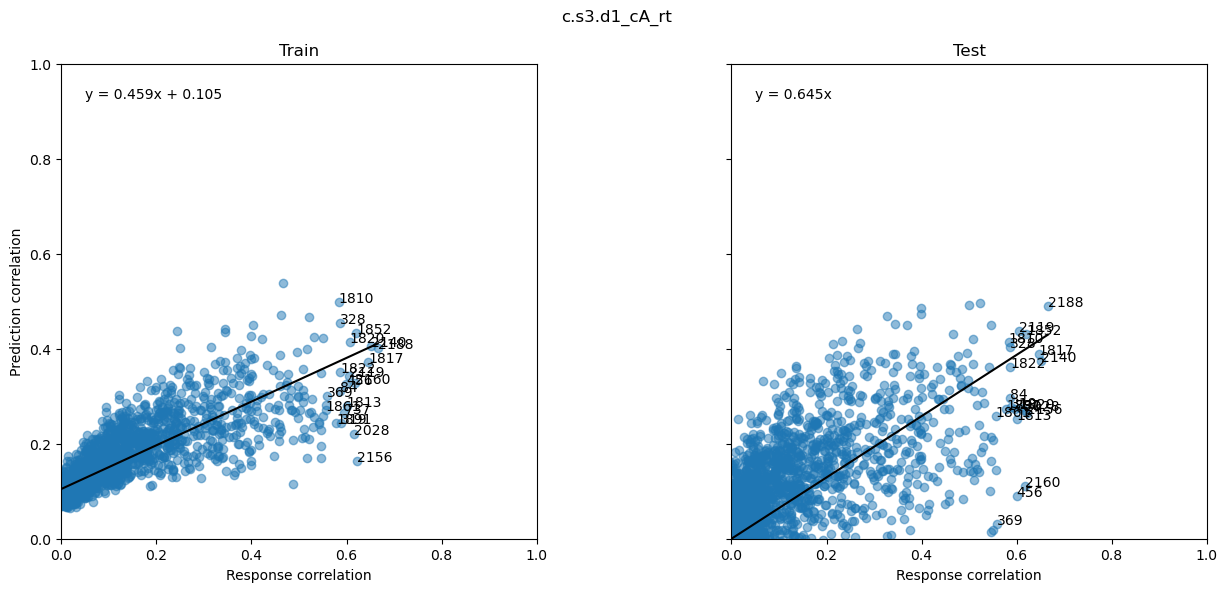

train fit: y = 0.459483 x + 0.104813
test fit : y = 0.644789 x
Using dwt mode: c.s3.d1_Lt0, feature dimension number: 7


Gaussian smoothing: 100%|██████████| 5/5 [00:06<00:00,  1.25s/it]


    stim_flat shape: (10710, 80640) (n_timepoints=10710, n_features=80640)
    resp shape: (10710, 2254) (n_timepoints=10710, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 9/9 [00:01<00:00,  5.26it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    92.09 MB  | shape=(2254, 10710)  dtype=torch.float32
| S_chunk             :    26.15 MB  | shape=(640, 10710)  dtype=torch.float32
| rfs_chunk           :     5.50 MB  | shape=(2254, 640)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   123.74 MB (  1.0%) | RESERVED:  1642.00 MB ( 13.4%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 6, 4, 8, 6, 5, 7, 2) (neurons=2254, feature_dims=(6, 4, 8, 6, 5, 7, 2))
Mean respcorr of largest 20 neurons: 0.603
Mean rfs_correlation of largest 20 neurons (train performance): 0.282
Mean rfs_correlation of largest 20 neurons (test performance): 0.172


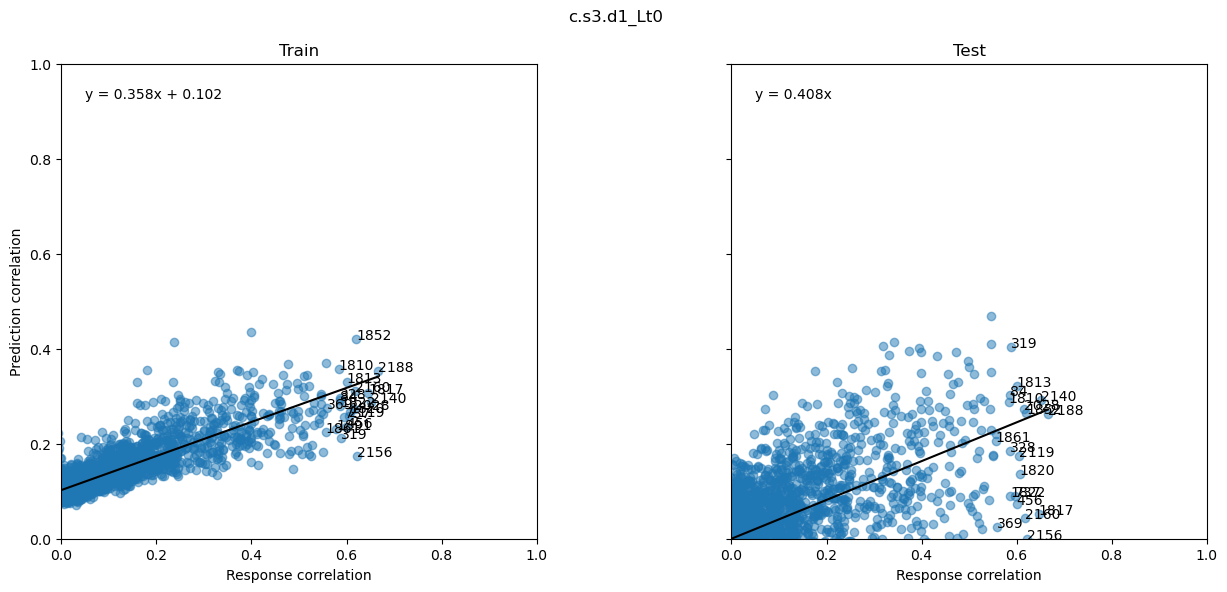

train fit: y = 0.358322 x + 0.102427
test fit : y = 0.408106 x
Using dwt mode: c.s3.d1_Lt0^2, feature dimension number: 7


Gaussian smoothing: 100%|██████████| 5/5 [00:07<00:00,  1.52s/it]


    stim_flat shape: (10710, 80640) (n_timepoints=10710, n_features=80640)
    resp shape: (10710, 2254) (n_timepoints=10710, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 9/9 [00:01<00:00,  4.75it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    92.09 MB  | shape=(2254, 10710)  dtype=torch.float32
| S_chunk             :    26.15 MB  | shape=(640, 10710)  dtype=torch.float32
| rfs_chunk           :     5.50 MB  | shape=(2254, 640)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   123.74 MB (  1.0%) | RESERVED:  1642.00 MB ( 13.4%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 6, 4, 8, 6, 5, 7, 2) (neurons=2254, feature_dims=(6, 4, 8, 6, 5, 7, 2))
Mean respcorr of largest 20 neurons: 0.603
Mean rfs_correlation of largest 20 neurons (train performance): 0.307
Mean rfs_correlation of largest 20 neurons (test performance): 0.170


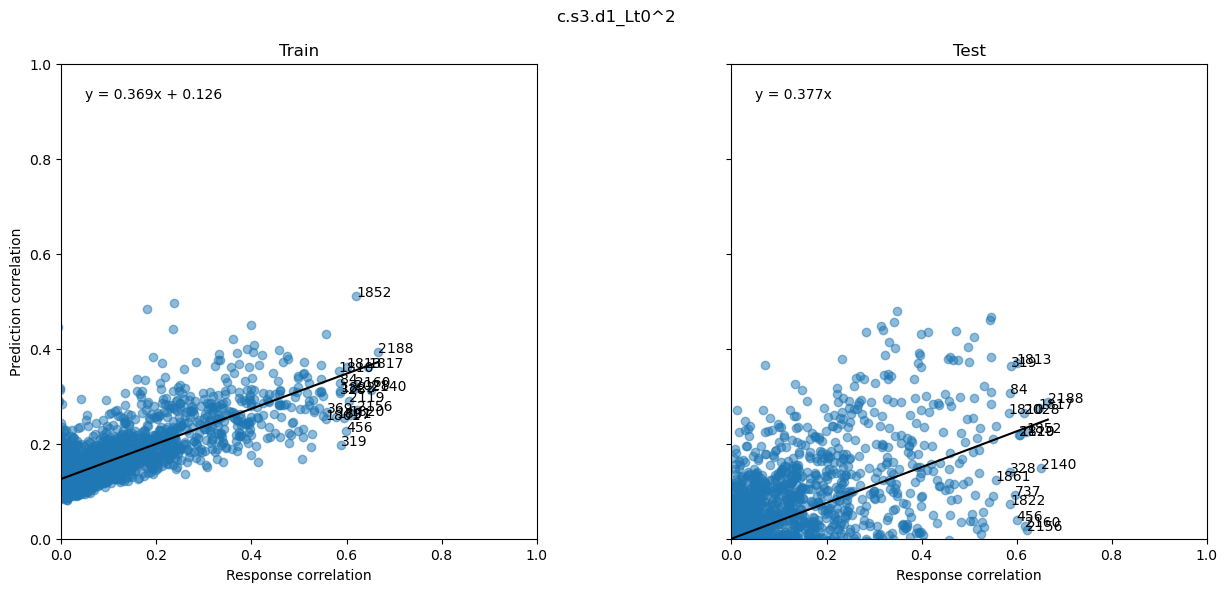

train fit: y = 0.368832 x + 0.126013
test fit : y = 0.376580 x
Using dwt mode: c.s3.d1_Lt0_rt, feature dimension number: 7


Gaussian smoothing: 100%|██████████| 5/5 [00:06<00:00,  1.24s/it]


    stim_flat shape: (10710, 80640) (n_timepoints=10710, n_features=80640)
    resp shape: (10710, 2254) (n_timepoints=10710, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 9/9 [00:01<00:00,  5.02it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    92.09 MB  | shape=(2254, 10710)  dtype=torch.float32
| S_chunk             :    26.15 MB  | shape=(640, 10710)  dtype=torch.float32
| rfs_chunk           :     5.50 MB  | shape=(2254, 640)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   123.74 MB (  1.0%) | RESERVED:  1642.00 MB ( 13.4%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 6, 4, 8, 6, 5, 7, 2) (neurons=2254, feature_dims=(6, 4, 8, 6, 5, 7, 2))
Mean respcorr of largest 20 neurons: 0.603
Mean rfs_correlation of largest 20 neurons (train performance): 0.223
Mean rfs_correlation of largest 20 neurons (test performance): 0.166


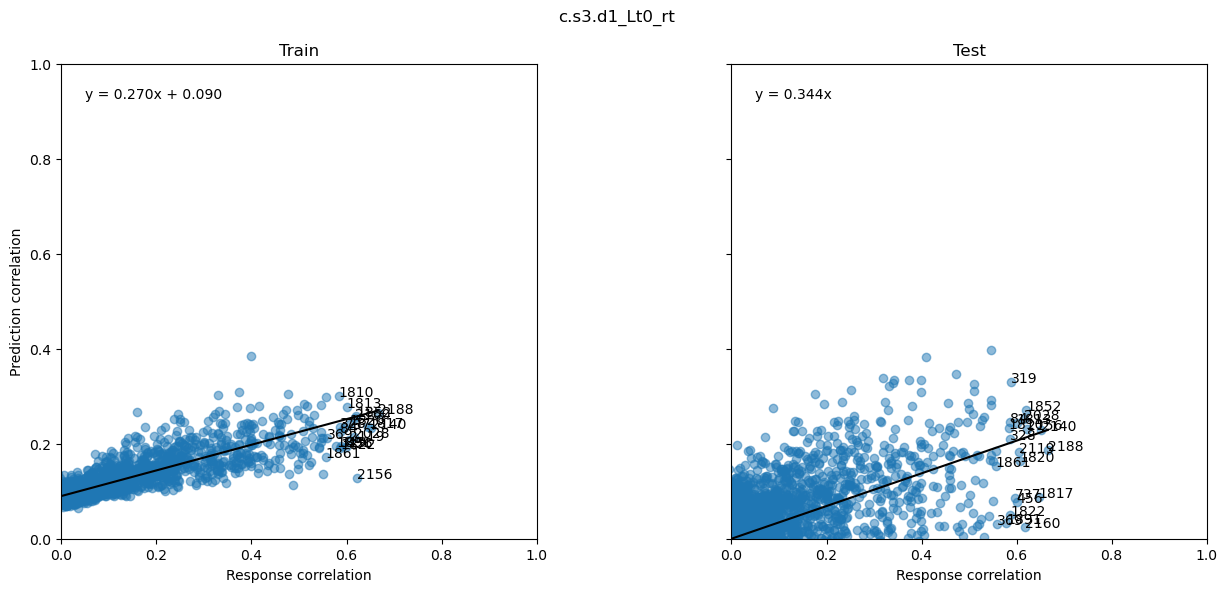

train fit: y = 0.269735 x + 0.089854
test fit : y = 0.343880 x
>>>>>>>>>>>Finished all modes. 


100%|██████████| 2254/2254 [00:00<00:00, 2467.61it/s]


D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0409_zebra5\ZEBRA_ANALYSIS\gaborLibrary_vS_6_4_8_6_5_7_2_af1d308a_c.s3.d1_


In [7]:
_, cstat = full_analysis_vSpeed3(spks_path, downsampled_video_path,  n_phases=2, phase_max=np.pi, nx=6, comment="c", smooth_fwhm_samples=average_FWHM_samples, shift_samples=1)

D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0409_zebra5\ZEBRA_ANALYSIS\resps_all.npy
Screen size: 100x75 pixels
Full screen coverage: [-88, 0, -33, 33] degrees
Visual coverage: [-88, 0, -33, 33] degrees
Angles (degrees): [  0.   22.5  45.   67.5  90.  112.5 135.  157.5]
Sizes (degrees): [ 4.          5.51891865  7.61461575 10.50611122 14.49559327 20.        ]
Frequencies (cycles/degree): [0.025      0.03912711 0.06123724 0.09584147 0.15      ]
Phases (degrees): [  0.  90. 180. 270.]
Drifts (degrees/frame): [-4.         -2.66666667 -1.33333333  0.          1.33333333  2.66666667
  4.        ]
Total number of Gabor filters to generate: 1290240
Control: Gabor placement step in visual degrees (x): 5.5, vs size_min: 4.0 degrees. WARNING!
Control: Gabor placement step in visual degrees (y): 5.5, vs size_min: 4.0 degrees. WARNING!
Control: Gabor resolution in visual degrees (x): 0.9, vs 1/freq_max: 6.7 degrees. OK
Control: Gabor resolution in visual degrees (y): 0.9, vs 1/freq_max: 6.7

Computing split-half correlation per neuron: 100%|██████████| 2254/2254 [00:05<00:00, 446.94it/s]


Working directory: D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0409_zebra5\ZEBRA_ANALYSIS
Train split at 85.0% of timepoints, test split at 15.0% of timepoints
Saved Gabor filter parameters to D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0409_zebra5\ZEBRA_ANALYSIS\gaborLibrary_vS_16_12_8_6_5_7_4_ca696278_p.s3.d1_
>>>>>>>>dwt shape: (12600, 16, 12, 8, 6, 5, 7, 4)
Using dwt mode: p.s3.d1_orig, feature dimension number: 7


Gaussian smoothing: 100%|██████████| 65/65 [03:32<00:00,  3.26s/it]


    stim_flat shape: (10710, 1290240) (n_timepoints=10710, n_features=1290240)
    resp shape: (10710, 2254) (n_timepoints=10710, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 130/130 [00:44<00:00,  2.95it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    92.09 MB  | shape=(2254, 10710)  dtype=torch.float32
| S_chunk             :     9.81 MB  | shape=(240, 10710)  dtype=torch.float32
| rfs_chunk           :     2.06 MB  | shape=(2254, 240)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   103.96 MB (  0.8%) | RESERVED:  1642.00 MB ( 13.4%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 16, 12, 8, 6, 5, 7, 4) (neurons=2254, feature_dims=(16, 12, 8, 6, 5, 7, 4))
Mean respcorr of largest 20 neurons: 0.603
Mean rfs_correlation of largest 20 neurons (train performance): 0.162
Mean rfs_correlation of largest 20 neurons (test performance): 0.095


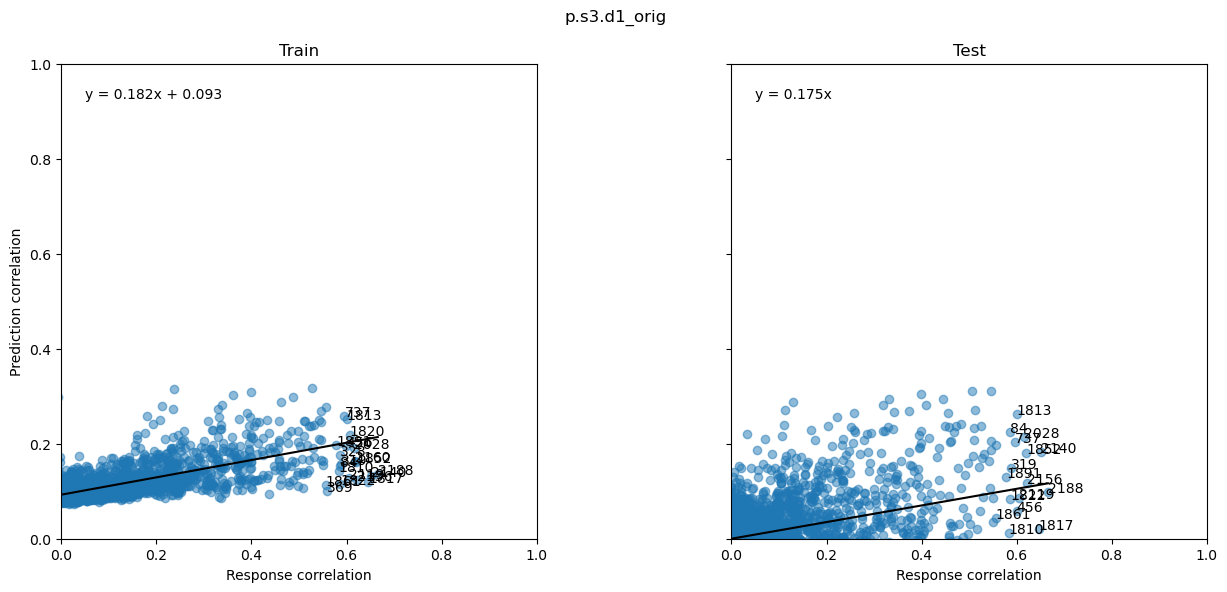

train fit: y = 0.182115 x + 0.092738
test fit : y = 0.175032 x
Using dwt mode: p.s3.d1_Gt0, feature dimension number: 7


Gaussian smoothing: 100%|██████████| 65/65 [02:02<00:00,  1.89s/it]


    stim_flat shape: (10710, 1290240) (n_timepoints=10710, n_features=1290240)
    resp shape: (10710, 2254) (n_timepoints=10710, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 130/130 [00:45<00:00,  2.87it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    92.09 MB  | shape=(2254, 10710)  dtype=torch.float32
| S_chunk             :     9.81 MB  | shape=(240, 10710)  dtype=torch.float32
| rfs_chunk           :     2.06 MB  | shape=(2254, 240)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   103.96 MB (  0.8%) | RESERVED:  1642.00 MB ( 13.4%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 16, 12, 8, 6, 5, 7, 4) (neurons=2254, feature_dims=(16, 12, 8, 6, 5, 7, 4))
Mean respcorr of largest 20 neurons: 0.603
Mean rfs_correlation of largest 20 neurons (train performance): 0.319
Mean rfs_correlation of largest 20 neurons (test performance): 0.240


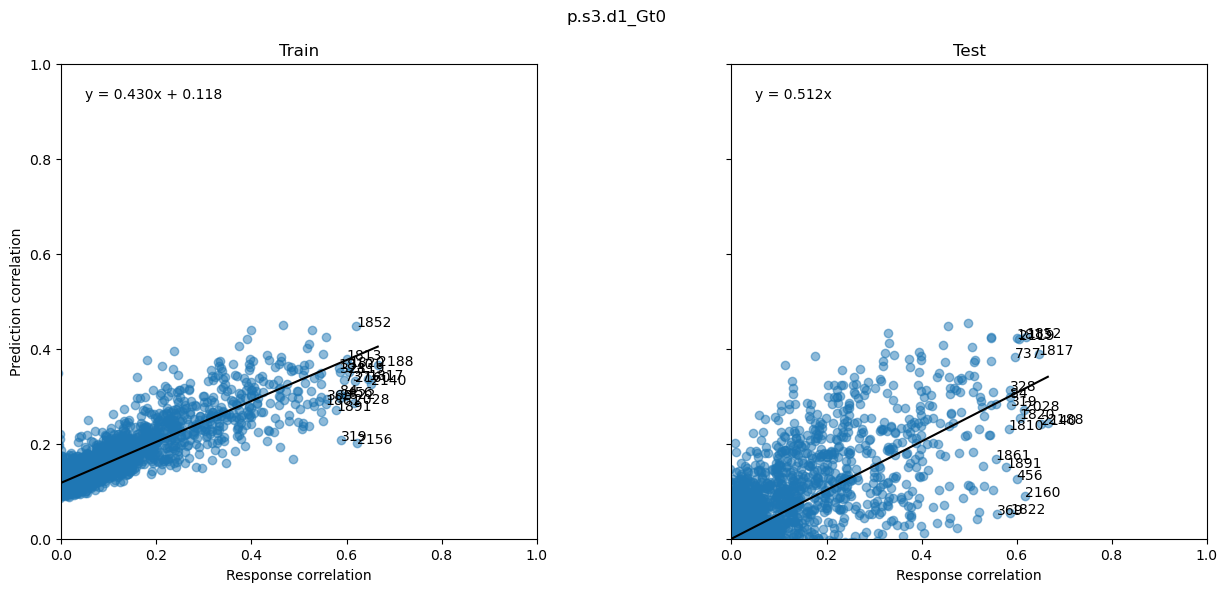

train fit: y = 0.430077 x + 0.117932
test fit : y = 0.511846 x
Using dwt mode: p.s3.d1_Gt0^2, feature dimension number: 7


Gaussian smoothing: 100%|██████████| 65/65 [02:49<00:00,  2.61s/it]


    stim_flat shape: (10710, 1290240) (n_timepoints=10710, n_features=1290240)
    resp shape: (10710, 2254) (n_timepoints=10710, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 130/130 [00:45<00:00,  2.88it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    92.09 MB  | shape=(2254, 10710)  dtype=torch.float32
| S_chunk             :     9.81 MB  | shape=(240, 10710)  dtype=torch.float32
| rfs_chunk           :     2.06 MB  | shape=(2254, 240)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   103.96 MB (  0.8%) | RESERVED:  1642.00 MB ( 13.4%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 16, 12, 8, 6, 5, 7, 4) (neurons=2254, feature_dims=(16, 12, 8, 6, 5, 7, 4))
Mean respcorr of largest 20 neurons: 0.603
Mean rfs_correlation of largest 20 neurons (train performance): 0.359
Mean rfs_correlation of largest 20 neurons (test performance): 0.246


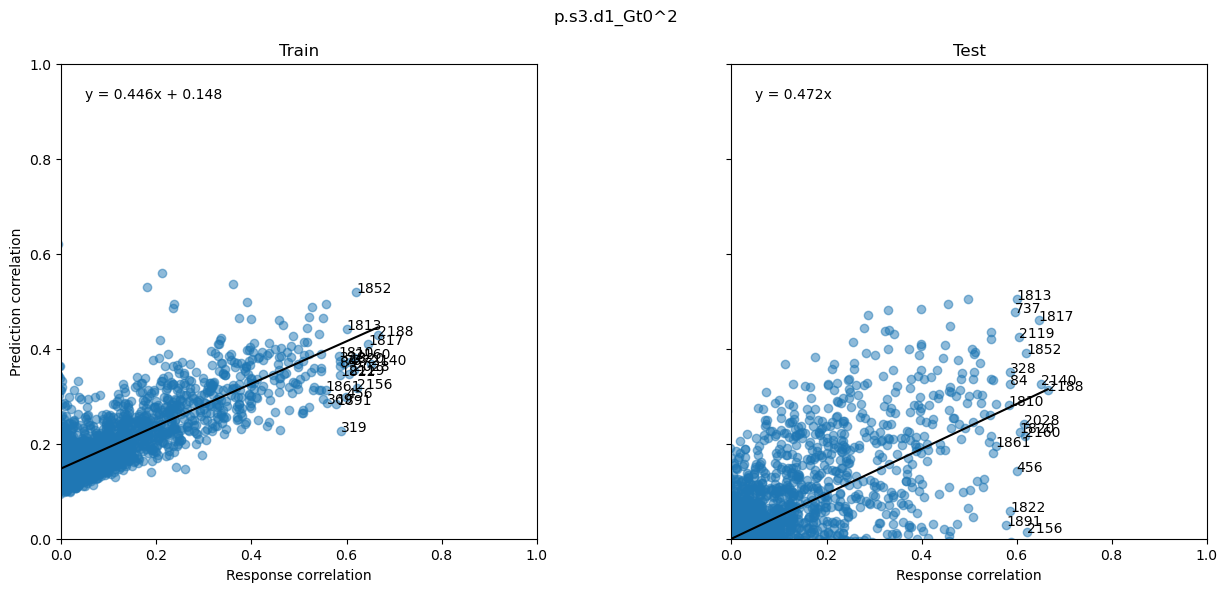

train fit: y = 0.445579 x + 0.148084
test fit : y = 0.472417 x
Using dwt mode: p.s3.d1_Gt0_rt, feature dimension number: 7


Gaussian smoothing: 100%|██████████| 65/65 [02:20<00:00,  2.16s/it]


    stim_flat shape: (10710, 1290240) (n_timepoints=10710, n_features=1290240)
    resp shape: (10710, 2254) (n_timepoints=10710, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 130/130 [00:38<00:00,  3.38it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    92.09 MB  | shape=(2254, 10710)  dtype=torch.float32
| S_chunk             :     9.81 MB  | shape=(240, 10710)  dtype=torch.float32
| rfs_chunk           :     2.06 MB  | shape=(2254, 240)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   103.96 MB (  0.8%) | RESERVED:  1642.00 MB ( 13.4%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 16, 12, 8, 6, 5, 7, 4) (neurons=2254, feature_dims=(16, 12, 8, 6, 5, 7, 4))
Mean respcorr of largest 20 neurons: 0.603
Mean rfs_correlation of largest 20 neurons (train performance): 0.257
Mean rfs_correlation of largest 20 neurons (test performance): 0.220


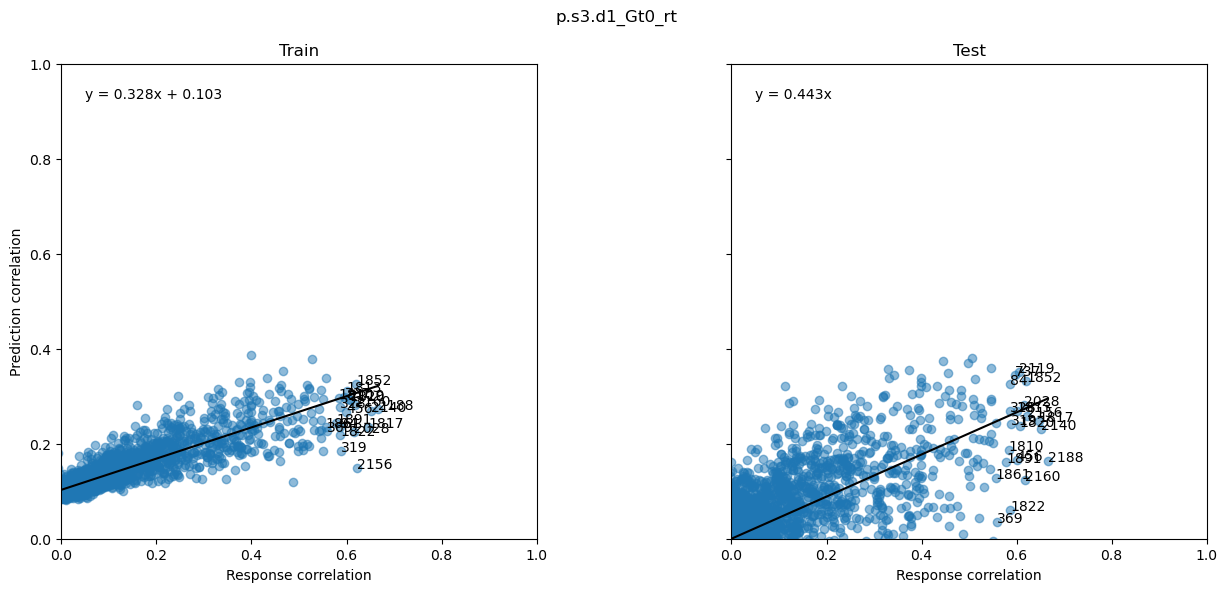

train fit: y = 0.328268 x + 0.102965
test fit : y = 0.443195 x
Using dwt mode: p.s3.d1_abs, feature dimension number: 7


Gaussian smoothing: 100%|██████████| 65/65 [03:17<00:00,  3.05s/it]


    stim_flat shape: (10710, 1290240) (n_timepoints=10710, n_features=1290240)
    resp shape: (10710, 2254) (n_timepoints=10710, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 130/130 [00:43<00:00,  2.97it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    92.09 MB  | shape=(2254, 10710)  dtype=torch.float32
| S_chunk             :     9.81 MB  | shape=(240, 10710)  dtype=torch.float32
| rfs_chunk           :     2.06 MB  | shape=(2254, 240)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   103.96 MB (  0.8%) | RESERVED:  1642.00 MB ( 13.4%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 16, 12, 8, 6, 5, 7, 4) (neurons=2254, feature_dims=(16, 12, 8, 6, 5, 7, 4))
Mean respcorr of largest 20 neurons: 0.603
Mean rfs_correlation of largest 20 neurons (train performance): 0.368
Mean rfs_correlation of largest 20 neurons (test performance): 0.297


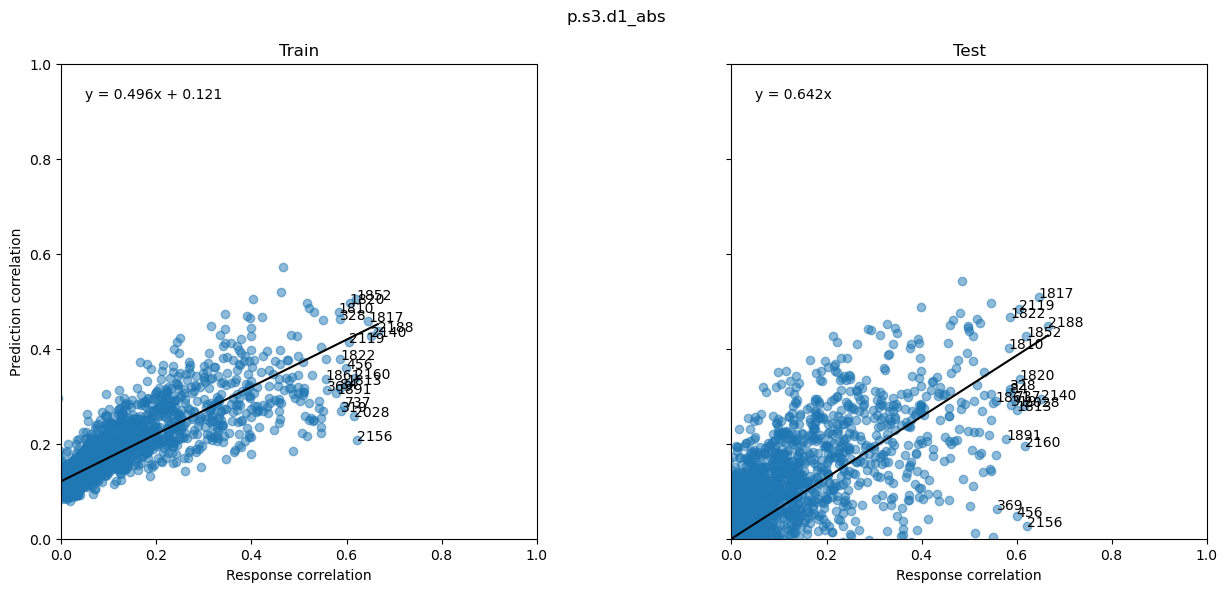

train fit: y = 0.496098 x + 0.121229
test fit : y = 0.642485 x
Using dwt mode: p.s3.d1_abs^2, feature dimension number: 7


Gaussian smoothing: 100%|██████████| 65/65 [02:50<00:00,  2.62s/it]


    stim_flat shape: (10710, 1290240) (n_timepoints=10710, n_features=1290240)
    resp shape: (10710, 2254) (n_timepoints=10710, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 130/130 [00:44<00:00,  2.89it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    92.09 MB  | shape=(2254, 10710)  dtype=torch.float32
| S_chunk             :     9.81 MB  | shape=(240, 10710)  dtype=torch.float32
| rfs_chunk           :     2.06 MB  | shape=(2254, 240)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   103.96 MB (  0.8%) | RESERVED:  1642.00 MB ( 13.4%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 16, 12, 8, 6, 5, 7, 4) (neurons=2254, feature_dims=(16, 12, 8, 6, 5, 7, 4))
Mean respcorr of largest 20 neurons: 0.603
Mean rfs_correlation of largest 20 neurons (train performance): 0.387
Mean rfs_correlation of largest 20 neurons (test performance): 0.290


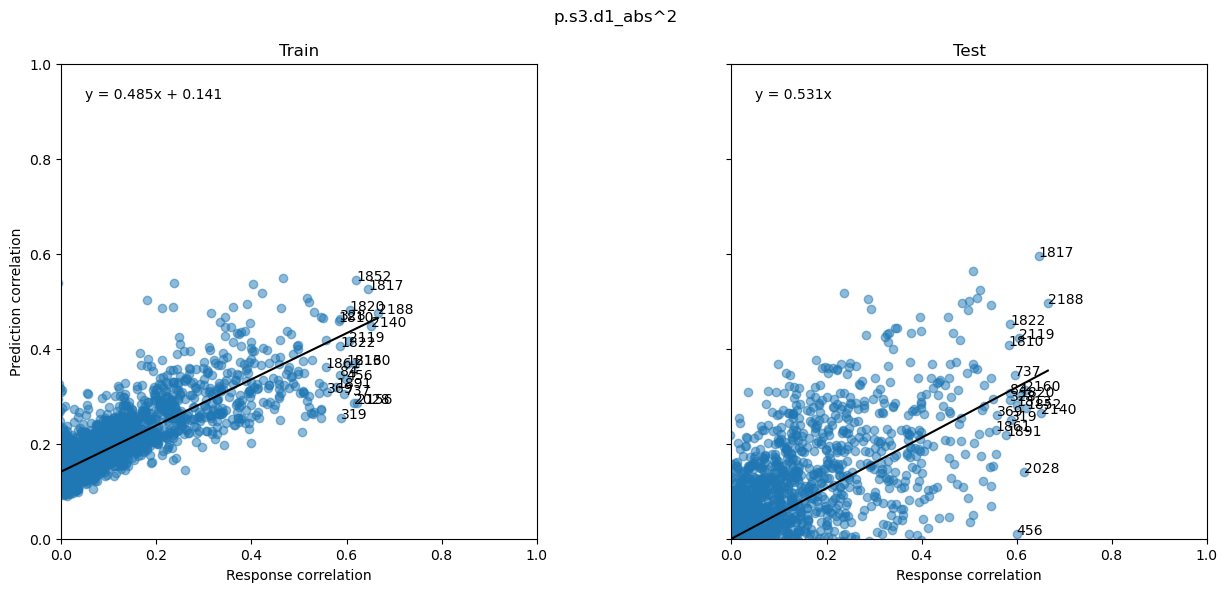

train fit: y = 0.485021 x + 0.141487
test fit : y = 0.531363 x
Using dwt mode: p.s3.d1_abs_rt, feature dimension number: 7


Gaussian smoothing: 100%|██████████| 65/65 [02:51<00:00,  2.63s/it]


    stim_flat shape: (10710, 1290240) (n_timepoints=10710, n_features=1290240)
    resp shape: (10710, 2254) (n_timepoints=10710, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 130/130 [00:48<00:00,  2.65it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    92.09 MB  | shape=(2254, 10710)  dtype=torch.float32
| S_chunk             :     9.81 MB  | shape=(240, 10710)  dtype=torch.float32
| rfs_chunk           :     2.06 MB  | shape=(2254, 240)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   103.96 MB (  0.8%) | RESERVED:  1642.00 MB ( 13.4%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 16, 12, 8, 6, 5, 7, 4) (neurons=2254, feature_dims=(16, 12, 8, 6, 5, 7, 4))
Mean respcorr of largest 20 neurons: 0.603
Mean rfs_correlation of largest 20 neurons (train performance): 0.341
Mean rfs_correlation of largest 20 neurons (test performance): 0.314


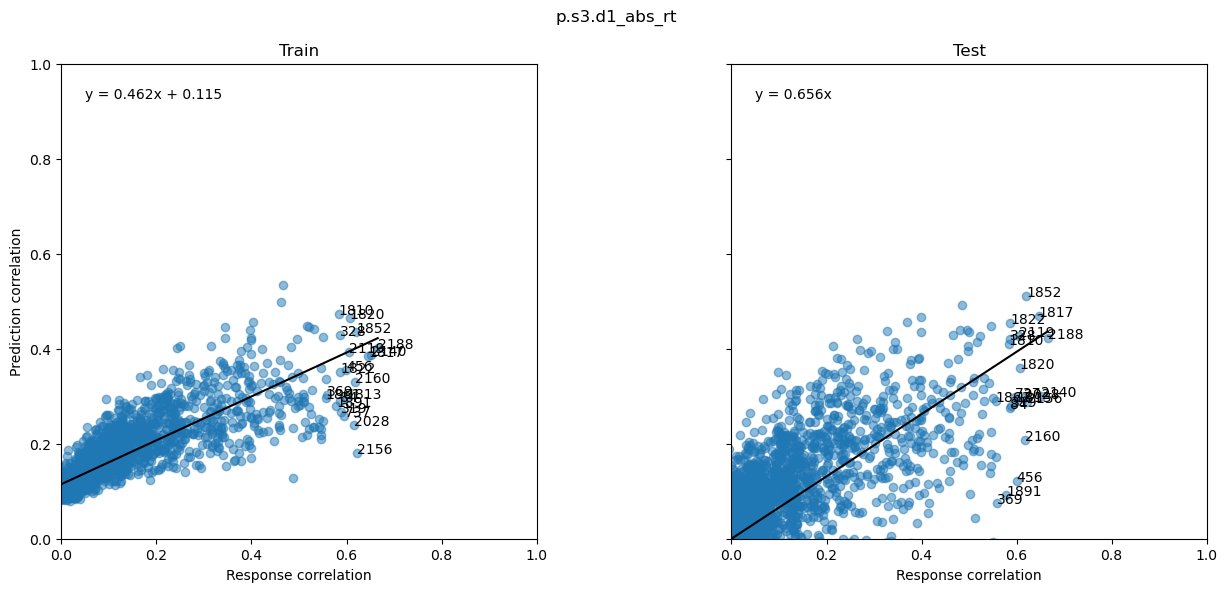

train fit: y = 0.461504 x + 0.114840
test fit : y = 0.655647 x
For complex representation, n_phases must be 2., skipping complex modes.
For complex representation, n_phases must be 2., skipping complex modes.
For complex representation, n_phases must be 2., skipping complex modes.
Using dwt mode: p.s3.d1_Lt0, feature dimension number: 7


Gaussian smoothing: 100%|██████████| 65/65 [02:20<00:00,  2.16s/it]


    stim_flat shape: (10710, 1290240) (n_timepoints=10710, n_features=1290240)
    resp shape: (10710, 2254) (n_timepoints=10710, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 130/130 [00:44<00:00,  2.93it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    92.09 MB  | shape=(2254, 10710)  dtype=torch.float32
| S_chunk             :     9.81 MB  | shape=(240, 10710)  dtype=torch.float32
| rfs_chunk           :     2.06 MB  | shape=(2254, 240)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   103.96 MB (  0.8%) | RESERVED:  1642.00 MB ( 13.4%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 16, 12, 8, 6, 5, 7, 4) (neurons=2254, feature_dims=(16, 12, 8, 6, 5, 7, 4))
Mean respcorr of largest 20 neurons: 0.603
Mean rfs_correlation of largest 20 neurons (train performance): 0.319
Mean rfs_correlation of largest 20 neurons (test performance): 0.240


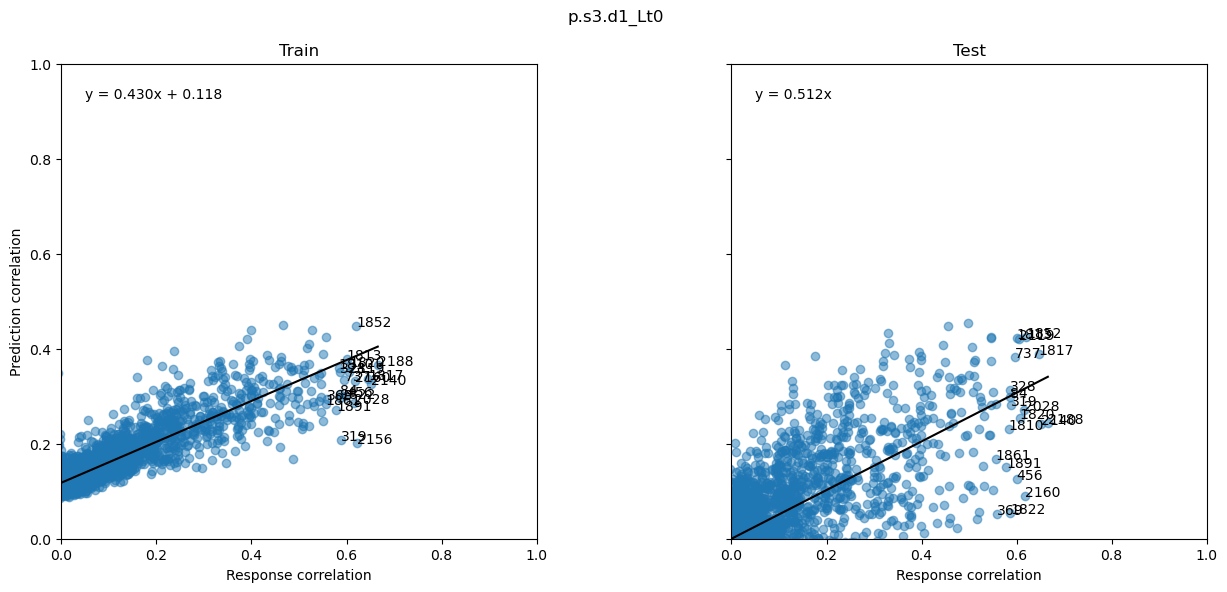

train fit: y = 0.430077 x + 0.117932
test fit : y = 0.511846 x
Using dwt mode: p.s3.d1_Lt0^2, feature dimension number: 7


Gaussian smoothing: 100%|██████████| 65/65 [03:01<00:00,  2.80s/it]


    stim_flat shape: (10710, 1290240) (n_timepoints=10710, n_features=1290240)
    resp shape: (10710, 2254) (n_timepoints=10710, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 130/130 [00:42<00:00,  3.02it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    92.09 MB  | shape=(2254, 10710)  dtype=torch.float32
| S_chunk             :     9.81 MB  | shape=(240, 10710)  dtype=torch.float32
| rfs_chunk           :     2.06 MB  | shape=(2254, 240)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   103.96 MB (  0.8%) | RESERVED:  1642.00 MB ( 13.4%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 16, 12, 8, 6, 5, 7, 4) (neurons=2254, feature_dims=(16, 12, 8, 6, 5, 7, 4))
Mean respcorr of largest 20 neurons: 0.603
Mean rfs_correlation of largest 20 neurons (train performance): 0.359
Mean rfs_correlation of largest 20 neurons (test performance): 0.246


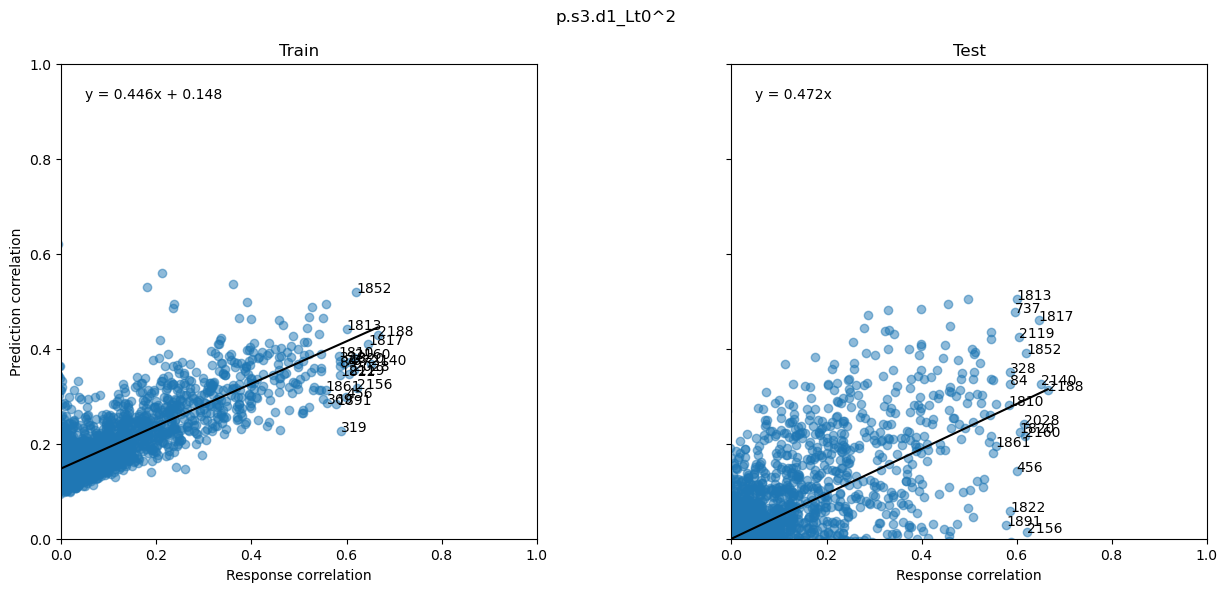

train fit: y = 0.445579 x + 0.148084
test fit : y = 0.472417 x
Using dwt mode: p.s3.d1_Lt0_rt, feature dimension number: 7


Gaussian smoothing: 100%|██████████| 65/65 [02:20<00:00,  2.16s/it]


    stim_flat shape: (10710, 1290240) (n_timepoints=10710, n_features=1290240)
    resp shape: (10710, 2254) (n_timepoints=10710, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 130/130 [00:42<00:00,  3.03it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    92.09 MB  | shape=(2254, 10710)  dtype=torch.float32
| S_chunk             :     9.81 MB  | shape=(240, 10710)  dtype=torch.float32
| rfs_chunk           :     2.06 MB  | shape=(2254, 240)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   103.96 MB (  0.8%) | RESERVED:  1642.00 MB ( 13.4%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 16, 12, 8, 6, 5, 7, 4) (neurons=2254, feature_dims=(16, 12, 8, 6, 5, 7, 4))
Mean respcorr of largest 20 neurons: 0.603
Mean rfs_correlation of largest 20 neurons (train performance): 0.257
Mean rfs_correlation of largest 20 neurons (test performance): 0.220


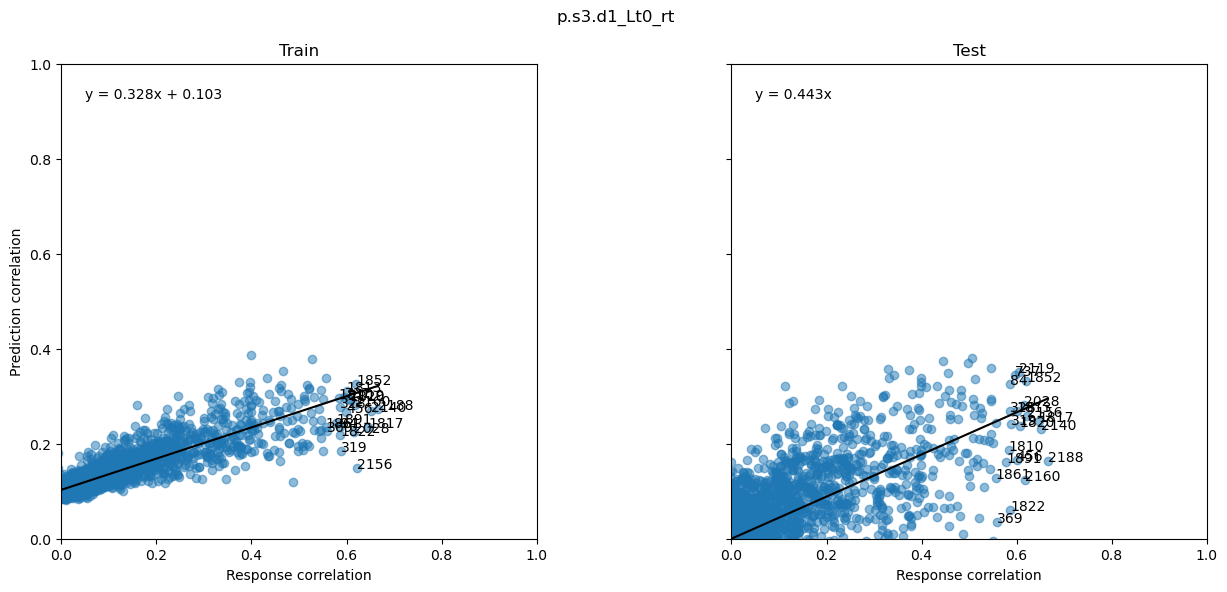

train fit: y = 0.328268 x + 0.102965
test fit : y = 0.443195 x
>>>>>>>>>>>Finished all modes. 


100%|██████████| 2254/2254 [00:00<00:00, 6731.32it/s]


D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0409_zebra5\ZEBRA_ANALYSIS\gaborLibrary_vS_16_12_8_6_5_7_4_ca696278_p.s3.d1_


In [8]:
_, cstat = full_analysis_vSpeed3(spks_path, downsampled_video_path,  comment="p", nx=16, smooth_fwhm_samples=average_FWHM_samples, shift_samples=1)

In [ ]:
for i in range(5):
    
    
    if i==4:
        
    else:
        
        
    # add cstat to stat summary expecting 1 line in the xlsx
    stat_summary=pd.read_excel(stat_summary_file)
    stat_summary = pd.concat([stat_summary, pd.DataFrame([cstat])], ignore_index=True)
    stat_summary.to_excel(stat_summary_file, index=False)
    
print("================ DONE nx down =================")


In [ ]:
for afwhm_sec in [ 0, 0.1, 0.2, 0.33, 0.5, 1]:
    afwhm_samples = int(np.round(target_fps * afwhm_sec))
    if afwhm_sec > 0:
        spks_afwhm = gaussian_filter1d(spks, sigma=afwhm_samples / 2.355,  axis=1)
    else:
        spks_afwhm = spks
    print(f"----- Time-averaged spks with FWHM={afwhm_sec:.2f}sec")

    for i in [1,2,5]:
        
        if i in [4,5]:
            _, cstat = full_analysis_vSpeed2(spks_path, downsampled_video_path, mode=i, n_phases=2, phase_max=np.pi, nx=20, spks=spks_afwhm, comment=f"afwhm{afwhm_sec:.2f}sec_") 
        else:
            _, cstat = full_analysis_vSpeed2(spks_path, downsampled_video_path, mode=i, nx=20, spks=spks_afwhm, comment=f"afwhm{afwhm_sec:.2f}sec_")
            
        # add cstat to stat summary expecting 1 line in the xlsx
        stat_summary=pd.read_excel(stat_summary_file)
        stat_summary = pd.concat([stat_summary, pd.DataFrame([cstat])], ignore_index=True)
        stat_summary.to_excel(stat_summary_file, index=False)
    
print("================ DONE =================")


In [ ]:
for i in range(5):
    
    if i==4:
        _, cstat = full_analysis_vSpeed2(spks_path, downsampled_video_path, mode=4, n_phases=2, phase_max=np.pi, nx=20, n_thetas=4)
    else:
        _, cstat = full_analysis_vSpeed2(spks_path, downsampled_video_path, mode=i, nx=20, n_thetas=4)
        
    # add cstat to stat summary expecting 1 line in the xlsx
    stat_summary=pd.read_excel(stat_summary_file)
    stat_summary = pd.concat([stat_summary, pd.DataFrame([cstat])], ignore_index=True)
    stat_summary.to_excel(stat_summary_file, index=False)
    
print("================ DONE theta =================")


In [ ]:
for i in range(5):
    stat_summary=pd.read_excel(stat_summary_file)
    
    if i==4:
        _, cstat = full_analysis_vSpeed2(spks_path, downsampled_video_path, mode=4, n_phases=2, phase_max=np.pi, nx=20, n_sizes=8, size_max=30)
    else:
        _, cstat = full_analysis_vSpeed2(spks_path, downsampled_video_path, mode=i, nx=20, n_sizes=8, size_max=30)
        
    # add cstat to stat summary expecting 1 line in the xlsx
    stat_summary = pd.concat([stat_summary, pd.DataFrame([cstat])], ignore_index=True)
    stat_summary.to_excel(stat_summary_file, index=False)
    
print("================ DONE sizes =================")

In [ ]:
for i in range(5):
    stat_summary=pd.read_excel(stat_summary_file)
    
    if i==4:
        _, cstat = full_analysis_vSpeed2(spks_path, downsampled_video_path, mode=4, n_phases=2, phase_max=np.pi, nx=20, n_freqs=9)
    else:
        _, cstat = full_analysis_vSpeed2(spks_path, downsampled_video_path, mode=i, nx=20, n_freqs=9)
        
    # add cstat to stat summary expecting 1 line in the xlsx
    stat_summary = pd.concat([stat_summary, pd.DataFrame([cstat])], ignore_index=True)
    stat_summary.to_excel(stat_summary_file, index=False)
    
print("================ DONE freqs =================")


In [ ]:
for i in range(5):
    stat_summary=pd.read_excel(stat_summary_file)
    
    if i==4:
        _, cstat = full_analysis_vSpeed2(spks_path, downsampled_video_path, mode=4, n_phases=2, phase_max=np.pi, nx=20, driftnum=7)
    else:
        _, cstat = full_analysis_vSpeed2(spks_path, downsampled_video_path, mode=i, nx=20, driftnum=7)
        
    # add cstat to stat summary expecting 1 line in the xlsx
    stat_summary = pd.concat([stat_summary, pd.DataFrame([cstat])], ignore_index=True)
    stat_summary.to_excel(stat_summary_file, index=False)
    
print("================ DONE drift =================")


In [ ]:
for i in range(5):
    stat_summary=pd.read_excel(stat_summary_file)
    
    if i==4:
        _, cstat = full_analysis_vSpeed2(spks_path, downsampled_video_path, mode=4, n_phases=2, phase_max=np.pi, nx=20, screen_t=3)
    else:
        _, cstat = full_analysis_vSpeed2(spks_path, downsampled_video_path, mode=i, nx=20, screen_t=3)
        
    # add cstat to stat summary expecting 1 line in the xlsx
    stat_summary = pd.concat([stat_summary, pd.DataFrame([cstat])], ignore_index=True)
    stat_summary.to_excel(stat_summary_file, index=False)
    
print("================ DONE screen_t =================")


In [ ]:
for i in range(5):
    stat_summary=pd.read_excel(stat_summary_file)
    
    if i==4:
        _, cstat = full_analysis_vSpeed2(spks_path, downsampled_video_path, mode=4, n_phases=2, phase_max=np.pi, nx=20, screen_t=7)
    else:
        _, cstat = full_analysis_vSpeed2(spks_path, downsampled_video_path, mode=i, nx=20, screen_t=7)
        
    # add cstat to stat summary expecting 1 line in the xlsx
    stat_summary = pd.concat([stat_summary, pd.DataFrame([cstat])], ignore_index=True)
    stat_summary.to_excel(stat_summary_file, index=False)
    
print("================ DONE screen_t 7 =================")


In [ ]:
for i in range(5):
    stat_summary=pd.read_excel(stat_summary_file)
    
    if i==4:
        pass# _, cstat = full_analysis_vSpeed2(spks_path, downsampled_video_path, mode=4, n_phases=2, phase_max=np.pi, nx=20, screen_t=7)
    else:
        _, cstat = full_analysis_vSpeed2(spks_path, downsampled_video_path, mode=i, nx=20, n_phases=8)
        
    # add cstat to stat summary expecting 1 line in the xlsx
    stat_summary = pd.concat([stat_summary, pd.DataFrame([cstat])], ignore_index=True)
    stat_summary.to_excel(stat_summary_file, index=False)
    
print("================ DONE phases =================")


In [ ]:
for i in range(5):
    stat_summary=pd.read_excel(stat_summary_file)
    
    if i==4:
        _, cstat = full_analysis_vSpeed2(spks_path, downsampled_video_path, mode=4, n_phases=2, phase_max=np.pi, nx=16)
    else:
        _, cstat = full_analysis_vSpeed2(spks_path, downsampled_video_path, mode=i, nx=16)
        
    # add cstat to stat summary expecting 1 line in the xlsx
    stat_summary = pd.concat([stat_summary, pd.DataFrame([cstat])], ignore_index=True)
    stat_summary.to_excel(stat_summary_file, index=False)
    
print("================ DONE nx down =================")
